# The Ralph Wiggum Loop: A Stochastic Retry Policy for LLM Agents

![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/ralphwiggum_loop_banner.jpg)

The Ralph Wiggum loop is a retry policy for AI work: feed the model the same task until it produces a verifiable completion, or hit a safety cap. The name comes from the Simpsons character, which is a fair description of an LLM that keeps trying until something sticks. Geoffrey Huntley wrote up the technique in mid-2025, and a Claude Code plugin now automates the same loop.

The idea sounds trivial, but it has real arithmetic behind it. Once each iteration is treated as an independent Bernoulli trial, three operational quantities fall out for free: completion time is geometric, expected iterations are $1/p$, and expected cost is $c/p$. Those three results decide when Ralph is worth running, when it's a money pit, and where prompt engineering still pays off.

```mermaid
flowchart LR
    A[Prompt] --> B[LLM call]
    B --> C{Completion<br/>verified?}
    C -- No --> D[Feedback into next<br/>prompt via filesystem]
    D --> B
    C -- Yes --> E[Stop]
    B --> F{Iteration<br/>cap reached?}
    F -- Yes --> E
```

Each box is one pass through the loop. The model itself is stateless. The loop works because the environment (files on disk, failing tests, logs) is not.

## Notebook Setup

Everything local in this notebook runs on CPU. The live Ralph demo and the prompt-strictness measurement call OpenRouter, so without an `OPENROUTER_API_KEY` in `.env` those sections print a notice and skip. The default model is `meta-llama/llama-3.2-1b-instruct`, listed at $0.027 per million input tokens and $0.20 per million output tokens on OpenRouter, so a short repair iteration costs a fraction of a cent and single-shot success is unreliable.

In [1]:
# Optional environment bootstrap for a fresh Kaggle or Colab session.
# If you already created the environment from requirements.txt or environment.yml, skip this cell.
# %pip install numpy scipy matplotlib openai python-dotenv

In [12]:
import platform
import random

import matplotlib.pyplot as plt
import numpy as np
import scipy

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng(42)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

print(f"Python {platform.python_version()}  |  NumPy {np.__version__}  |  SciPy {scipy.__version__}")

Python 3.12.12  |  NumPy 2.2.6  |  SciPy 1.14.1


## The Mechanism

In cartoon form, the plugin version is essentially a single shell line:

```bash
while :; do cat PROMPT.md | claude ; done
```

The real loop has more structure around that line: a stop hook blocks exit, some verifier decides whether the work is done, failing state feeds back into the next prompt, and a max-iteration cap stops the run if progress stalls. The core idea is unchanged. The model reads the same prompt again, but the environment has changed underneath it.

That persistent environment carries memory across iterations even though the model does not. That asymmetry is also where the geometric assumption can break, because state from previous iterations can change the odds of the next.

![Huntley's Ralph process diagram, showing the generate / back-pressure cycle with subagents fanned out for reads and a single serialised verifier](images/The-ralph-Process.png)

Huntley's own diagram of the technique splits the loop into a generate phase and a back-pressure phase, with subagents fanned out for cheap reads while a single agent handles the expensive verifier. That split is exactly what keeps $p$ roughly stationary across iterations: a deterministic stack (specs, plan, agent file) goes in every loop, and the verifier signal is the same kind each time.

The key move in the whole notebook is this: treat each iteration as a Bernoulli trial. Success with probability $p$, otherwise retry. The probability $p$ stands for everything that affects whether one pass produces a passing artifact: prompt quality, model capability, task difficulty, and how strict the back-pressure is (tests, linters, type checkers). Any retry-until-pass loop wrapped around a stochastic worker (an LLM, a flaky CI job, a noisy sensor) admits the same modelling step, and the same three results fall out the other side.

The model is deliberately weak. It assumes iterations are independent, which the real loop isn't, because the filesystem carries state between passes. We'll use that gap at the end to read the histograms and tell a healthy loop from a stuck one.

The code below is an example of this:

In [13]:
def bernoulli_attempt(p):
    return random.random() < p


def ralph_loop_sim(p, max_iterations):
    for i in range(1, max_iterations + 1):
        if bernoulli_attempt(p):
            return i, True
    return max_iterations, False

With $p = 0.1$ the simulator finishes quickly. With $p = 0$ it hits the cap, which is the only thing distinguishing a productive loop from an infinite one.

In [14]:
random.seed(42)
i, ok = ralph_loop_sim(p=0.10, max_iterations=50)
print(f"p=0.10 -> finished={ok} at iteration {i}")

i, ok = ralph_loop_sim(p=0.0, max_iterations=20)
print(f"p=0.00 -> finished={ok} at iteration {i} (hit cap, as expected)")

p=0.10 -> finished=True at iteration 2
p=0.00 -> finished=False at iteration 20 (hit cap, as expected)


The first call succeeds at iteration 2 (one weighted coin came up heads on the second flip), and the $p=0$ run sits at the cap because there's nothing to flip towards. That cap is also the only thing keeping a real Ralph run from spinning forever when the model can't ever solve the task.

## Modelling Ralph

The toy simulator is fine for measuring properties of the loop. To see Ralph behave on a real model, we run it against `meta-llama/llama-3.2-1b-instruct`, a buggy Python function, and six unit tests including an empty-list edge case. The seed function has two defects: it crashes on empty input at `xs[0]`, and it drops the first element via `return out[1:]`. The model isn't constrained to fix those defects directly. It rewrites from scratch and tends to invent its own characteristic failures, which is more honest than scripting the answer. The completion promise is the test suite returning green. Each failed iteration feeds the failing test output back into the next prompt, which is what the real Ralph plugin does through the file system.

Temperature is set to $0.8$ so iterations actually diverge. At low temperature a 1B model happily emits the same wrong fix every iteration, which would look indistinguishable from a mock. To keep the loop auditable, each iteration prints the OpenRouter response id, the input/output token counts, and a SHA-1 of the returned code. Different ids and different hashes are the evidence that real, distinct calls happened.

Any other OpenRouter model substitutes by setting `RALPH_MODEL` in the environment.

### The Verifier

The verifier doesn't read the model's reply, it runs the code and checks the function against six tests. PASS only fires if every call returns exactly the expected list, so back-pressure comes from reality rather than the model's confidence.

In [15]:
import hashlib
import os
import re
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE = os.getenv("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1")
MODEL_ID = os.getenv("RALPH_MODEL", "meta-llama/llama-3.2-1b-instruct")


In [16]:
BUGGY = """
def running_max(xs):
    out = []
    m = xs[0]
    for x in xs:
        if x > m:
            m = x
        out.append(m)
    return out[1:]
"""

TESTS = [
    ([3, 1, 4, 1, 5, 9, 2, 6], [3, 3, 4, 4, 5, 9, 9, 9]),
    ([1], [1]),
    ([5, 4, 3, 2, 1], [5, 5, 5, 5, 5]),
    ([-1, -2, 3], [-1, -1, 3]),
    ([], []),
    ([7, 7, 7], [7, 7, 7]),
]


def run_tests(code):
    ns = {}
    try:
        exec(code, ns)
        f = ns["running_max"]
    except Exception as e:
        return False, f"exec error: {type(e).__name__}: {e}"
    failures = []
    for inp, expected in TESTS:
        try:
            got = f(list(inp))
        except Exception as e:
            failures.append(f"running_max({inp!r}) raised {type(e).__name__}: {e}")
            continue
        if got != expected:
            failures.append(f"running_max({inp!r}) -> {got}, expected {expected}")
    if failures:
        return False, "\n".join(failures[:3])
    return True, f"all {len(TESTS)} tests pass"


def extract_code(text):
    m = re.search(r"```(?:python)?\s*(.*?)```", text, re.S)
    return m.group(1) if m else text


if not OPENROUTER_KEY:
    print("OPENROUTER_API_KEY not set. Skipping the live Ralph demo.")
else:
    client = OpenAI(api_key=OPENROUTER_KEY, base_url=OPENROUTER_BASE)
    system = (
        "You are a careful Python developer. "
        "Reply with only a single ```python``` code block containing the fixed function. "
        "No prose, no explanation."
    )
    base_user = (
        "Fix this function so all unit tests pass, including the empty-list case. "
        "Return only the corrected function in one ```python``` code block.\n\n"
        f"```python\n{BUGGY.strip()}\n```"
    )
    print(f"Model: {MODEL_ID}  (temperature=0.8, max_iter=6)\n")
    user = base_user
    MAX_ITER_LIVE = 6
    for i in range(1, MAX_ITER_LIVE + 1):
        resp = client.chat.completions.create(
            model=MODEL_ID,
            messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
            max_tokens=400,
            temperature=0.8,
        )
        code = extract_code(resp.choices[0].message.content)
        ok, msg = run_tests(code)
        sha = hashlib.sha1(code.encode()).hexdigest()[:8]
        usage = resp.usage
        toks = f"{usage.prompt_tokens}->{usage.completion_tokens}"
        print(f"  [{i}] resp_id=...{str(resp.id)[-12:]}  tokens(in->out)={toks}  code_sha1={sha}  {'PASS' if ok else 'FAIL'}")
        for ln in code.strip().splitlines():
            print(f"        | {ln}")
        if ok:
            print(f"\n  Completed in {i} iteration(s).")
            break
        print(f"        first failing test: {msg.splitlines()[0]}")
        user = base_user + f"\n\nAttempt {i} failed with:\n{msg}\nTry a different approach this time."
    else:
        print(f"\n  Hit cap of {MAX_ITER_LIVE}. The model is in a fixed point, which is itself a real Ralph failure mode.")

Model: meta-llama/llama-3.2-1b-instruct  (temperature=0.8, max_iter=6)

  [1] resp_id=...g75fdAwBF2Nt  tokens(in->out)=120->25  code_sha1=848607cb  FAIL
        | def running_max(xs):
        |     return [x for x in xs if x > xs[0]]
        first failing test: running_max([3, 1, 4, 1, 5, 9, 2, 6]) -> [4, 5, 9, 6], expected [3, 3, 4, 4, 5, 9, 9, 9]
  [2] resp_id=...bwYL1xiARbEg  tokens(in->out)=244->64  code_sha1=b0ae6fbd  PASS
        | def running_max(xs):
        |     if not xs:
        |         return []
        |     max_val = xs[0]
        |     out = [max_val]
        |     for x in xs[1:]:
        |         if x > max_val:
        |             max_val = x
        |         out.append(max_val)
        |     return out

  Completed in 2 iteration(s).


On this run, `llama-3.2-1b-instruct` opened with a junk one-liner that fails the very first test, then with that failure pasted back in produced a working fix on attempt two. The OpenRouter response ids and code SHA-1s change across iterations, which is the evidence that distinct calls are happening rather than one cached reply being replayed. A rerun need not take exactly two iterations, which is the point of treating the loop as stochastic rather than scripted.

A stuck run would show the same SHA-1 repeated across all six iterations under different response ids: the model genuinely sampling and genuinely failing in the same way each time. That's a real Ralph failure mode, and the fix is a stricter prompt or a stronger model, which is what the next two sections measure.

## Claim 1: Iterations Are Geometric

If each iteration succeeds independently with probability $p$, the number of iterations until the first success, $X$, is geometric:

$$P(X = k) = (1-p)^{k-1} p, \quad E[X] = \frac{1}{p}, \quad \mathrm{Var}(X) = \frac{1-p}{p^2}.$$

Each pass through the loop is another weighted coin toss, and the process stops on the first head.

The geometric model is a starting prior, useful precisely because deviations from it are interpretable. Real Ralph runs have memory through the filesystem, so iterations aren't strictly independent, and we'll come back to what the histograms tell us when they don't match. The simulation below uses 2,000 runs at $p = 0.08$, which is enough to see the geometric shape clearly.

E[X]  empirical = 12.713   theory (1/p) = 12.500
Var   empirical = 143.674   theory       = 143.750
chi^2 GoF vs Geometric(p=0.08): chi2 = 5.84, p-value = 0.665
  -> consistent with geometric at the 5% level


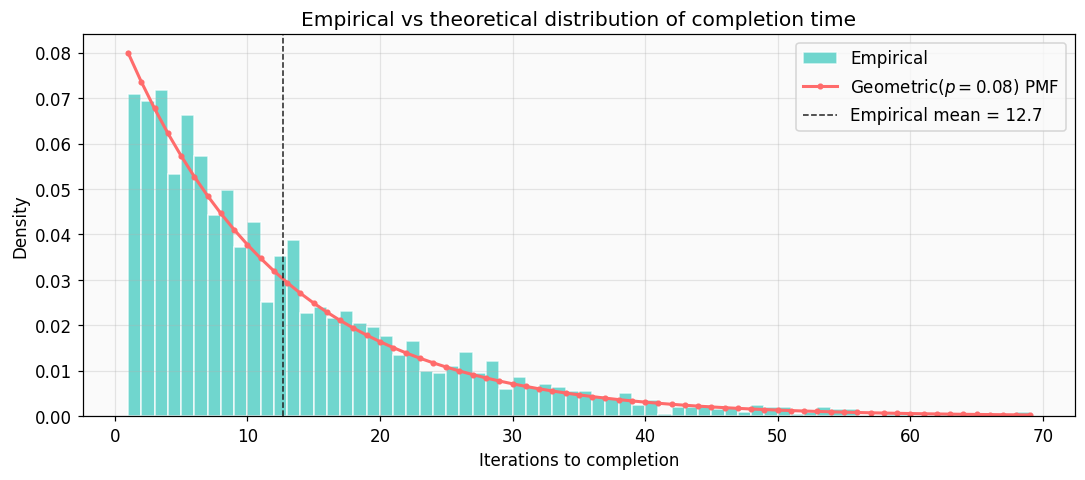

In [17]:
from scipy import stats

random.seed(42)
N_RUNS = 2000
MAX_ITER = 200
P_TRUE = 0.08

iters = []
for _ in range(N_RUNS):
    i, ok = ralph_loop_sim(P_TRUE, MAX_ITER)
    if ok:
        iters.append(i)
arr = np.array(iters)

mean_emp, mean_theory = arr.mean(), 1 / P_TRUE
var_emp, var_theory = arr.var(ddof=1), (1 - P_TRUE) / P_TRUE**2

edges = np.array([1, 4, 8, 12, 16, 20, 25, 30, 40, 200])
obs, _ = np.histogram(arr, bins=edges)
cdf_edges = stats.geom.cdf(edges - 1, P_TRUE)
exp_prob = np.diff(cdf_edges)
exp = exp_prob * len(arr) / (1 - stats.geom.cdf(edges[0] - 1, P_TRUE) - (1 - stats.geom.cdf(edges[-1] - 1, P_TRUE)))
chi2, chi2_p = stats.chisquare(obs, exp)

print(f"E[X]  empirical = {mean_emp:6.3f}   theory (1/p) = {mean_theory:6.3f}")
print(f"Var   empirical = {var_emp:6.3f}   theory       = {var_theory:6.3f}")
print(f"chi^2 GoF vs Geometric(p={P_TRUE}): chi2 = {chi2:.2f}, p-value = {chi2_p:.3f}")
print(f"  -> {'consistent with geometric' if chi2_p > 0.05 else 'rejects geometric'} at the 5% level")

ks = np.arange(1, 70)
pmf_theory = stats.geom.pmf(ks, P_TRUE)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(arr, bins=range(1, 70), density=True, color="#4ECDC4", edgecolor="white", alpha=0.8, label="Empirical")
ax.plot(ks, pmf_theory, color="#FF6B6B", linewidth=2, marker="o", markersize=3, label=f"Geometric($p={P_TRUE}$) PMF")
ax.axvline(mean_emp, color="#222", linestyle="--", linewidth=1, label=f"Empirical mean = {mean_emp:.1f}")
ax.set_xlabel("Iterations to completion")
ax.set_ylabel("Density")
ax.set_title("Empirical vs theoretical distribution of completion time")
ax.legend()
plt.tight_layout()
plt.show()

The empirical mean lands at 12.71 against a theoretical $1/p = 12.5$, and the empirical variance is 143.67 against $(1-p)/p^2 = 143.75$. Both match to about half a percent, which is the kind of agreement you'd expect from a true geometric process at this sample size. The chi-squared goodness-of-fit returns $p = 0.665$, well clear of the 5% threshold, so we can't reject the geometric null. In plot terms, the teal histogram tracks the red theoretical PMF closely across the bulk, including the long right tail out past 40 iterations.

This baseline is what the rest of the notebook compares real runs against. When a histogram from a Ralph run on actual code tightens around the mean (less variance than this picture), iterations are helping each other, and when it stretches further into the tail, iterations are interfering.

## Claim 2: Better Prompts Are Worth $1/p$

A prompt rule helps only when it removes a recurring failure mode. In this model, that shows up as a bigger $p$, and since mean iterations are $1/p$, the gain from a better prompt is

$$\Delta E[X] = \frac{1}{p} - \frac{1}{p + \Delta p}.$$

That function is steep at small $p$ and flat at large $p$. Lifting $p$ from $0.05$ to $0.10$ cuts the mean from $20$ iterations to $10$. The same $\Delta p = 0.05$ at $p = 0.50$ moves the mean from $2$ to $1.82$. Same edit, very different payoff.

The cell below measures $\hat{p}$ for three prompts of increasing strictness, single-shot, $N=15$ trials each. Like the live demo, it calls OpenRouter and skips cleanly if no key is present. On `running_max` the empty-list test is the dominant seeded failure mode, so the first rule that names it should do most of the work.

config             p_hat   1/p_hat
base                0.00       inf
+ empty list        0.87      1.15
+ same length       1.00      1.00


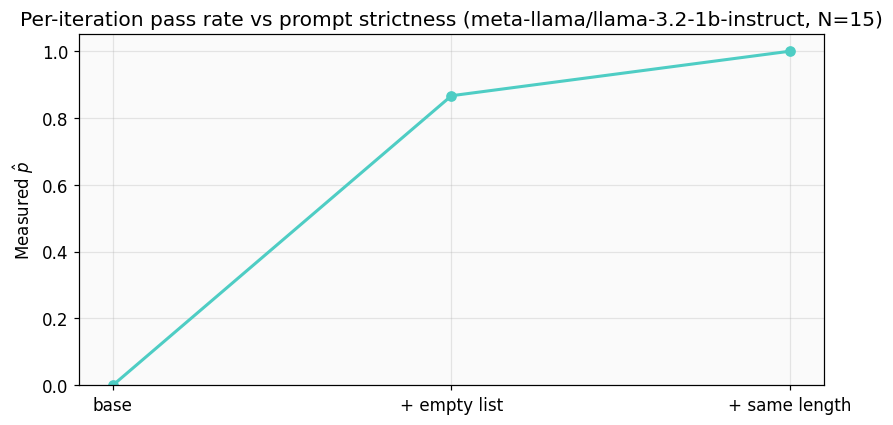

In [21]:
N_TRIALS = 15
PROMPT_CONFIGS = [
    ("base", []),
    ("+ empty list", ["Handle the empty input list by returning []."]),
    ("+ same length", ["Handle the empty input list by returning [].", "The output must have the same length as the input."]),
]

SYSTEM = "You are a careful Python developer. Reply with only a ```python``` code block."


def one_shot(client, rules):
    rules_block = "\n".join(f"- {r}" for r in rules) if rules else "(no extra rules)"
    user = f"Fix this function so all unit tests pass.\n\n```python\n{BUGGY.strip()}\n```\n\nRequirements:\n{rules_block}"
    resp = client.chat.completions.create(
        model=MODEL_ID,
        messages=[{"role": "system", "content": SYSTEM}, {"role": "user", "content": user}],
        max_tokens=400,
        temperature=0.7,
    )
    return extract_code(resp.choices[0].message.content)


if not OPENROUTER_KEY:
    print("OPENROUTER_API_KEY not set. Skipping the prompt-strictness measurement.")
else:
    client = OpenAI(api_key=OPENROUTER_KEY, base_url=OPENROUTER_BASE)
    print(f"{'config':<16s}  {'p_hat':>6}  {'1/p_hat':>8}")
    ns, ps = [], []
    for n, (name, rules) in enumerate(PROMPT_CONFIGS):
        successes = sum(run_tests(one_shot(client, rules))[0] for _ in range(N_TRIALS))
        p_hat = successes / N_TRIALS
        inv = 1 / p_hat if p_hat > 0 else float("inf")
        print(f"{name:<16s}  {p_hat:>6.2f}  {inv:>8.2f}")
        ns.append(n)
        ps.append(p_hat)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ns, ps, "o-", color="#4ECDC4", linewidth=2)
    ax.set_xticks(ns)
    ax.set_xticklabels([c[0] for c in PROMPT_CONFIGS])
    ax.set_ylabel(r"Measured $\hat{p}$")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-iteration pass rate vs prompt strictness ({MODEL_ID}, N={N_TRIALS})")
    plt.tight_layout()
    plt.show()

The base prompt gets 0 out of 15, so $\hat{p}=0$ and $1/\hat{p}$ is infinite. Naming the empty-list case lifts the model to 13 out of 15, so $\hat{p}$ jumps to about $0.87$ and the implied iteration budget falls to about $1.15$. Adding the same-length rule pushes this rerun to 15 out of 15. With $N=15$ trials and 15 successes, the two-sided 95% Clopper-Pearson lower bound on $p$ is about $0.78$, so we shouldn't read "1.00" as proof of perfect reliability, only as evidence that the remaining failure mode is now hard to trigger.

That's still diminishing returns, just in a less cartoonish shape. The first rule does most of the work because it targets the seeded empty-list failure. The second rule cleans up what is left and moves the pass rate the rest of the way. On a different task with several competing failure modes you would expect a smoother climb, but the operational point is the same: spend prompt effort where $p$ is small, and stop tuning once $p$ is comfortable.

## Claim 3: Expected Cost Is $c/p$

Cost is iterations multiplied by price per iteration. If each pass costs $c$ dollars and the loop is geometric,

$$E[\text{cost}] = c \cdot E[X] = \frac{c}{p}.$$

A weak prompt is affordable when calls are cheap. An expensive model is affordable when $p$ is high. Both together is the failure mode.

At current OpenRouter list prices, a short Llama 3.2 1B repair iteration with 1,000 input tokens and 300 output tokens costs about $\$0.000087$. At $p = 0.05$, expected cost is about $\$0.0017$. A larger code-repair iteration on Claude Sonnet 4 with 4,000 input tokens and 500 output tokens costs about $\$0.0195$ per pass. At the same $p = 0.05$, expected cost is about $\$0.39$.

That gives the model-choice rule. Two models break even when $c_1 / p_1 = c_2 / p_2$, so a more expensive model only pays for itself when its success probability climbs by the same factor as its price. Sonnet 4 is about 224x more expensive per iteration than Llama 3.2 1B in the example above, so on this task you'd need Sonnet's per-iteration success probability to be at least 224x higher than Llama's before Sonnet becomes the cheaper choice. That's the question to ask before reaching for a frontier model: do you really need 224x the $p$, or do you need a stricter prompt on the cheap model?

Llama 3.2 1B example    = $0.000087  (1K in + 300 out, OpenRouter list)
GPT-4.1 example         = $0.0044  (1K in + 300 out, OpenRouter list)
Claude Sonnet 4 example = $0.0195  (4K in + 500 out, OpenRouter list)
Per-iteration prob p    = 0.08
E[cost] observed        = $0.2479
E[cost] c/p             = $0.2437
95% of runs finish under $0.70


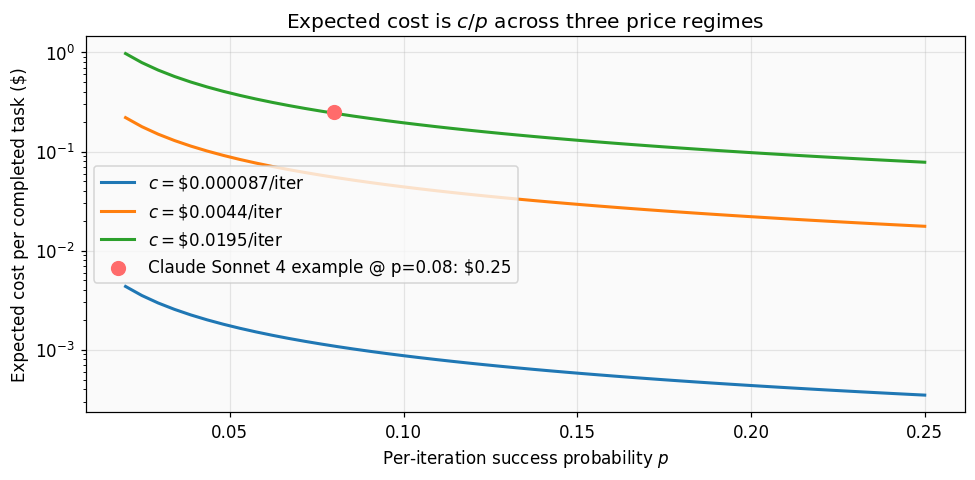

In [20]:
random.seed(42)
N_RUNS_COST = 2000
P_COST = 0.08
LLAMA_INPUT_PRICE = 0.027
LLAMA_OUTPUT_PRICE = 0.20
LLAMA_INPUT_TOKENS = 1_000
LLAMA_OUTPUT_TOKENS = 300
GPT41_INPUT_PRICE = 2.0
GPT41_OUTPUT_PRICE = 8.0
GPT41_INPUT_TOKENS = 1_000
GPT41_OUTPUT_TOKENS = 300
SONNET_INPUT_PRICE = 3.0
SONNET_OUTPUT_PRICE = 15.0
SONNET_INPUT_TOKENS = 4_000
SONNET_OUTPUT_TOKENS = 500

llama_cost = LLAMA_INPUT_TOKENS * LLAMA_INPUT_PRICE / 1_000_000 + LLAMA_OUTPUT_TOKENS * LLAMA_OUTPUT_PRICE / 1_000_000
gpt41_cost = GPT41_INPUT_TOKENS * GPT41_INPUT_PRICE / 1_000_000 + GPT41_OUTPUT_TOKENS * GPT41_OUTPUT_PRICE / 1_000_000
C_PER_ITER = SONNET_INPUT_TOKENS * SONNET_INPUT_PRICE / 1_000_000 + SONNET_OUTPUT_TOKENS * SONNET_OUTPUT_PRICE / 1_000_000

costs = []
for _ in range(N_RUNS_COST):
    i, ok = ralph_loop_sim(P_COST, 1000)
    if ok:
        costs.append(i * C_PER_ITER)
costs = np.array(costs)

mean_cost_obs = costs.mean()
mean_cost_theory = C_PER_ITER / P_COST
print(f"Llama 3.2 1B example    = ${llama_cost:.6f}  (1K in + 300 out, OpenRouter list)")
print(f"GPT-4.1 example         = ${gpt41_cost:.4f}  (1K in + 300 out, OpenRouter list)")
print(f"Claude Sonnet 4 example = ${C_PER_ITER:.4f}  (4K in + 500 out, OpenRouter list)")
print(f"Per-iteration prob p    = {P_COST}")
print(f"E[cost] observed        = ${mean_cost_obs:.4f}")
print(f"E[cost] c/p             = ${mean_cost_theory:.4f}")
print(f"95% of runs finish under ${np.percentile(costs, 95):.2f}")

probs = np.linspace(0.02, 0.25, 50)
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in [llama_cost, gpt41_cost, C_PER_ITER]:
    label = f"$c = \\${c:.6f}$/iter" if c < 0.001 else f"$c = \\${c:.4f}$/iter"
    ax.plot(probs, c / probs, linewidth=2, label=label)
ax.scatter([P_COST], [mean_cost_obs], color="#FF6B6B", s=80, zorder=5, label=f"Claude Sonnet 4 example @ p=0.08: ${mean_cost_obs:.2f}")
ax.set_xlabel("Per-iteration success probability $p$")
ax.set_ylabel("Expected cost per completed task ($)")
ax.set_title("Expected cost is $c/p$ across three price regimes")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

The observed mean cost is $0.2479$ against a theoretical $c/p = 0.2437$, within about 2% across 2,000 simulated runs. The 95th-percentile cost is $0.70$, which is the number to budget for if you care about worst case rather than average case. That worst-case-to-mean ratio of roughly 2.8x comes straight from the geometric tail.

The plot puts all three price regimes on a log scale, so a vertical line at any chosen $p$ tells you how many orders of magnitude separate the cheap and expensive models at that success rate. At $p = 0.08$ the gap between Llama and Sonnet is the full 224x ratio we computed in the prose. The same gap closes only if you can show Sonnet's per-iteration success rate is high enough to flip the inequality $c_1/p_1 = c_2/p_2$, which is the question worth asking before reaching for a frontier model.

## The Loop as a Regret Bound

The three claims look like separate facts. They're one fact under three reparameterisations. Define regret as iterations spent beyond the oracle (one shot, instant solve):

$$E[\text{regret}] = E[X] - 1 = \frac{1-p}{p}.$$

Multiplied by $c$, that's the cost result. Differentiated by $p$, that's why prompt tuning has diminishing returns: $\frac{d}{dp}\,E[\text{regret}] = -1/p^2$, so the same improvement $\Delta p$ matters most when $p$ is small. The first guardrail rule on a weak prompt is worth far more than the tenth on a decent one.

The geometric assumption is also doing more work than it looks. It's a prior over a memoryless loop. Real Ralph runs are implicitly Bayesian: the model itself is stateless, but the filesystem is the posterior, and the next attempt samples from $P(\text{success} \mid \text{partial edits, failing tests, prior outputs})$ rather than from a constant $p$. When that posterior drifts upward iteration over iteration, the completion-time distribution tightens relative to a geometric. When it drifts downward, the tail fattens. That's the diagnostic in the next section, restated in Bayesian terms.

In Huntley's own write-up, $p$ is held roughly stationary by deliberate operator hygiene: one task per loop, a fixed specs folder, a `fix_plan.md` and `AGENT.md` allocated into context every iteration, and subagents fanned out for expensive reads so the main context window stays small. None of that is decoration. It's what stops the posterior from wandering and keeps the geometric story usable as a baseline.

## When the Maths Holds, and When It Doesn't

The geometric story is a baseline, not a verdict. If partial progress accumulates, later iterations become more likely to succeed and the distribution tightens relative to a geometric. If iterations interfere through rate limits, context clutter, or bad local edits, the tail gets fatter. The histogram tells you which regime the loop is in: repeated fresh attempts, or a staged process.

Ralph is useful when success is machine-checkable, calls are cheap, and each retry has a real chance of getting over the line. It's much less useful when success is subjective, or when the model cannot recognise completion without a human in the loop. Huntley is also blunt about scope: Ralph is a Greenfield bootstrap, gets you maybe 90% of the way, and is not the technique to reach for inside an existing codebase where the verifier signal is muddied by prior decisions you didn't make.

## Takeaways

The whole notebook turns on one move. Wrap a stochastic worker in a retry-until-pass loop and you're looking at a Bernoulli process, whatever the worker happens to be (an LLM, a flaky CI job, a noisy sensor). From there the arithmetic is first-year probability and it gives you everything operational. Expected iterations $1/p$ tells you how long a run will take. Expected cost $c/p$ tells you what it costs, and the break-even $c_1/p_1 = c_2/p_2$ tells you when a frontier model is worth the bill on this task. When a real run doesn't look geometric, the histogram can point you toward why: a tighter peak suggests progress is accumulating across iterations, while a fatter tail suggests iterations are interfering. The joke makes Ralph memorable. The three formulas, $E[X] = 1/p$, $E[\text{cost}] = c/p$, and $E[\text{regret}] = (1-p)/p$, are what make it usable.

## References

1. Huntley, G. *Ralph Wiggum as a "software engineer"*, 14 July 2025. https://ghuntley.com/ralph/
2. Anthropic. *Claude Code documentation*. https://docs.claude.com/en/docs/claude-code
3. OpenRouter. *Model pricing*. https://openrouter.ai/models